In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from math import log as ln
# from math import atan as arctan
# from math import sqrt
# import math
from numpy import log as ln
from numpy import arctan
from numpy import sqrt
from numpy import cbrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

In [31]:
ds = pd.read_excel('data/ranichauri02-26.xlsx', engine='openpyxl')
ds['ts'] = (ds['TT_C_S_Avg'] + ds['TT_C_W_Avg']) / 2
# Convert ts from Celsius to Kelvin
ds['ts'] = ds['ts'] + 273.15
ds['AirTC_16m_Avg']+=273.15
ds['AirTC_8m_Avg']+=273.15
# Drop original columns
ds = ds.drop(columns=['TT_C_S_Avg', 'TT_C_W_Avg'])
ds.columns.tolist()

['WS_ms_8m_Avg',
 'WS_ms_16m_Avg',
 'AirTC_8m_Avg',
 'RH_8m',
 'AirTC_16m_Avg',
 'RH_16m',
 'T_27',
 'U_27',
 'u*',
 'H',
 'Tau',
 'L',
 'TIMESTAMP',
 'T_s',
 'RiB_s_27',
 'ts']

In [32]:

# Create new dataframe
df = pd.DataFrame({
    'timestamp': ds['TIMESTAMP'],
    'u0': np.zeros(len(ds)),
    't0': ds['ts'],
    'u8': ds['WS_ms_8m_Avg'],
    't8': ds['AirTC_8m_Avg'],
    'u16': ds['WS_ms_16m_Avg'],
    't16': ds['AirTC_16m_Avg'],
    'u27': ds['U_27'],
    't27': ds['T_27'],
    'rib_s' : ds['RiB_s_27'],
    'T_ss':ds['T_s']
})

# Heights corresponding to temperature measurements
heights = np.array([8, 16, 27])

# Function to compute T at 0.57 m
def compute_t057(row):
    temps = np.array([row['t8'], row['t16'], row['t27']])
    
    if np.any(np.isnan(temps)):
        return np.nan
    
    coeffs = np.polyfit(heights, temps, 2)
    return np.polyval(coeffs, 0.57)

# Apply row-wise
df['t57'] = df.apply(compute_t057, axis=1)
df['tavg'] = df[['t0','t8','t16','t27']].mean(axis=1)

print(df.head())

            timestamp   u0          t0        u8          t8       u16  \
0 2024-11-01 00:30:00  0.0  284.087528  2.099389  286.778944  2.674778   
1 2024-11-01 01:30:00  0.0  283.818639  2.024833  286.615222  2.344989   
2 2024-11-01 02:00:00  0.0  283.473111  1.946922  286.456444  2.125378   
3 2024-11-01 02:30:00  0.0  283.232028  1.626300  286.314167  2.272633   
4 2024-11-01 03:30:00  0.0  283.374528  2.185689  285.993833  2.314778   

          t16       u27        t27     rib_s        T_ss         t57  \
0  287.434611  3.707465  289.18442  0.166883  286.635303  286.635303   
1  287.232444  3.511267  288.93380  0.177064  286.509704  286.509704   
2  287.122500  3.206674  288.87204  0.225752  286.295171  286.295171   
3  286.995389  3.179595  288.75870  0.233894  286.134922  286.134922   
4  286.604944  3.588834  288.44196  0.172962  285.973015  285.973015   

         tavg  
0  286.871376  
1  286.650026  
2  286.481024  
3  286.325071  
4  286.103816  


In [5]:
def root(func, low, up, ribx, tolerance=1e-4, max_iterations=100):
    a = low
    b = up
    fa = func(a, ribx)
    fb = func(b, ribx)

    if fa*fb > 0:
        #print("None")
        return None

    for iteration in range(max_iterations):
        midpoint = (a + b) / 2.0
        fm = func(midpoint, ribx)
        
        if abs(fm) < tolerance:
            #print(iteration)
            return midpoint

        if (b - a) / 2.0 < tolerance:
            #print(iteration)
            return midpoint

        if fa*fm < 0:
            b = midpoint
            fb = fm
        else:
            a = midpoint
            fa = fm

    print("Failed to converge")
    return (a + b) / 2.0                                                                                                                                                                                                           

In [68]:
g = 9.81
def richard(z2,z1):
    T_avg = (X_by_height[z1]['t']+X_by_height[z2]['t'])/2
    Ri = (g * (X_by_height[z2]['t']-X_by_height[z1]['t']) * (z2-z1)) / (T_avg * (X_by_height[z2]['u']-X_by_height[z1]['u'])**2)

    Ri.name = f'Ri_{z1}_{z2}m'

    return Ri   
X_by_height = {
    0.57: {'u': df['u0'],  't': df['t57']},
    8:    {'u': df['u8'],  't': df['t8']},
    16:   {'u': df['u16'], 't': df['t16']},
    27:   {'u': df['u27'], 't': df['t27']}
}

In [7]:
a=6.1
b=2.5
c=5.3
d=1.1
def psi_stable(x,f): #Cheng and Brusteart   

    if f == 'm':
        y = -a*ln(x+(1+x**b)**(1/b))
    else:
        y = -c*ln(x+(1+x**d)**(1/d))
    return y

def psi_unstable(x,f):  
    if f == 'm':
        t1=(1-16*x)**0.25
        psibd = 2*ln((1+t1)/2) + ln((1+t1**2)/2) - 2*arctan(t1) + np.pi/2
        beta = 10
    else:
        t1=(1-16*x)**0.5
        psibd = 2*ln((1+t1)/2)
        beta = 34
    t2 = cbrt(1-beta*x)
    
    psic = (3/2)*ln((t2**2+t2+1)/3) - sqrt(3)*arctan((2*t2+1)/sqrt(3)) + np.pi/sqrt(3)

    y = (psibd+(x**2)*psic)/(1+x**2)
    return y

In [8]:
tresh = 0
def rib_bisec(x,ribx=0):
    x0 = x*zfac
    if ribx > tresh: #stable
        y = ribx - (x * (1-zfac)*((ln(1/zfac)-psi_stable(x,'h')+psi_stable(x0,'h')) / (ln(1/zfac)-psi_stable(x,'m')+psi_stable(x0,'m'))**2))
    else: #unstable
        y = ribx - (x * (1-zfac)*((ln(1/zfac)-psi_unstable(x,'h')+psi_unstable(x0,'h'))/(ln(1/zfac)-psi_unstable(x,'m')+psi_unstable(x0,'m'))**2))
    return y

11864 11864


0        0.167011
1        0.177180
2        0.225936
3        0.234095
4        0.173051
           ...   
11859    0.548643
11860    0.336934
11861    0.215915
11862   -0.146796
11863   -8.694860
Name: Ri_0.57_27m, Length: 11864, dtype: float64

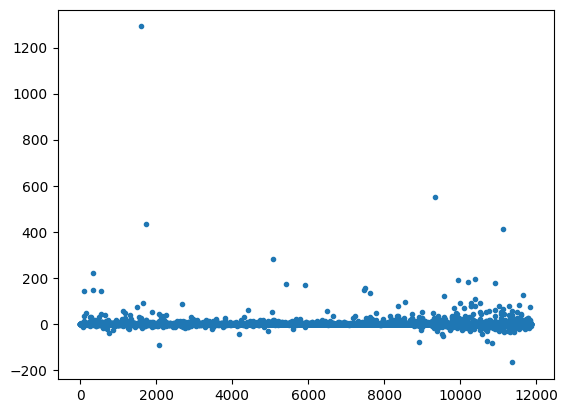

In [69]:
#Calculating richardson number
d=5.37
z0 = 0.57
z2 = 27 #higher level
z1 = 0.57 #lower level
zfac = z1/(z2-d)
rib= richard(z2, z1)

# # Remove NaN and inf first (VERY important for Ri)
# rib_full = rib_full[np.isfinite(rib_full)]

# # Compute percentiles
# p01 = np.percentile(rib_full, 0.5)
# p99 = np.percentile(rib_full, 99.5)

# # Keep only values between 1% and 99%
# rib = rib_full[(rib_full >= p01) & (rib_full <= p99)]
print(len(rib_full),len(rib))
plt.plot(rib,'.')
rib

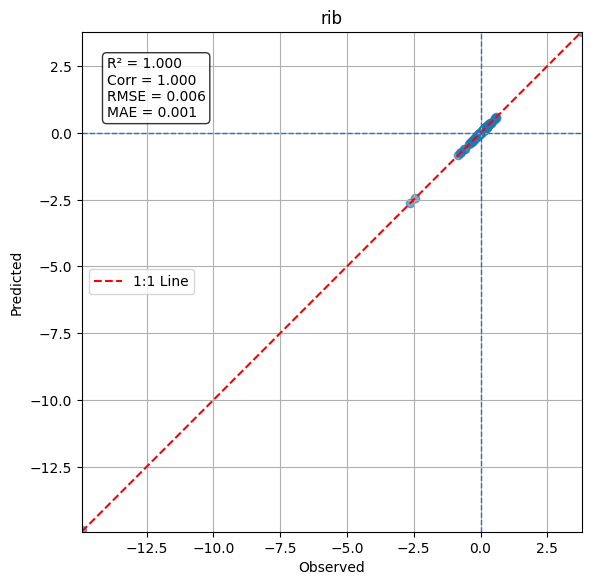

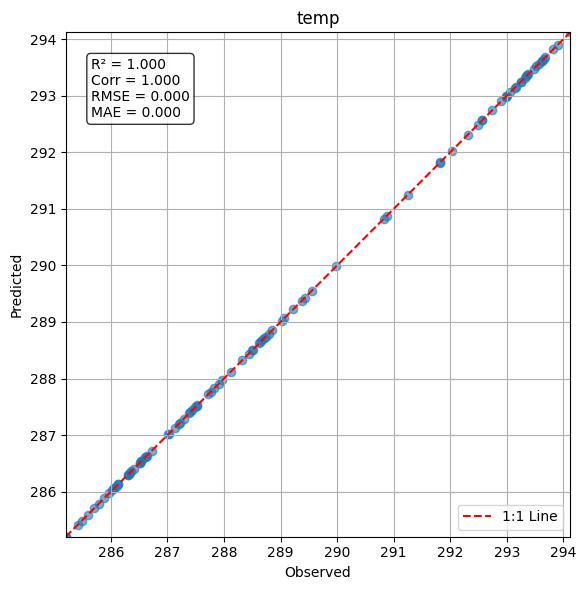

Correlation (rib vs RiB_s_27): 0.9999996061866218
Correlation (t57 vs T_ss): 0.9999999999999994


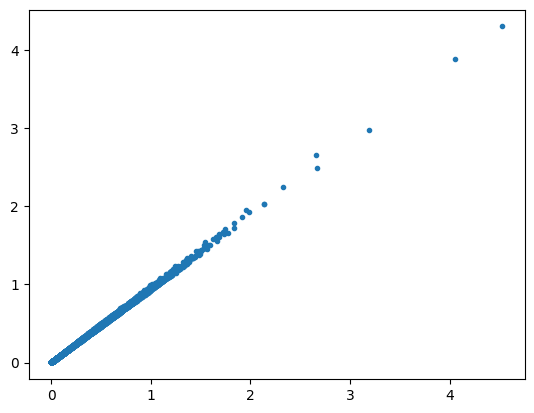

In [70]:
results_plot(rib,ds['RiB_s_27'],'rib')
plt.show()
results_plot(df['t57'],df['T_ss'],'temp')
mask = np.isfinite(rib) & np.isfinite(ds['RiB_s_27'])
corr1 = np.corrcoef(rib[mask], ds['RiB_s_27'][mask])[0,1]

print("Correlation (rib vs RiB_s_27):", corr1)
mask = np.isfinite(df['t57']) & np.isfinite(df['T_ss'])
corr2 = np.corrcoef(df['t57'][mask], df['T_ss'][mask])[0,1]
plt.show()
print("Correlation (t57 vs T_ss):", corr2)
plt.plot(ds['u*']**2,ds['Tau'],'.')

In [71]:
#Finding Eta for stable and unstable conditions

eta_stable = []
rib_eta_stable = []
ls = 0.0000
us = 100
ts_stable = []

eta_unstable = []
rib_eta_unstable = []
lu = -100
uu = -0.0000
ts_unstable = []


for stamp, ri_val in rib.items():
    if ri_val > 0:  # stable
        eta = root(rib_bisec, ls, us, ri_val)
        if eta is not None:
            eta_stable.append(eta)
            rib_eta_stable.append(ri_val)
            ts_stable.append(stamp)

    else:  # unstable
        eta = root(rib_bisec, lu, uu, ri_val)
        if eta is not None:
            eta_unstable.append(eta)
            rib_eta_unstable.append(ri_val)
            ts_unstable.append(stamp)


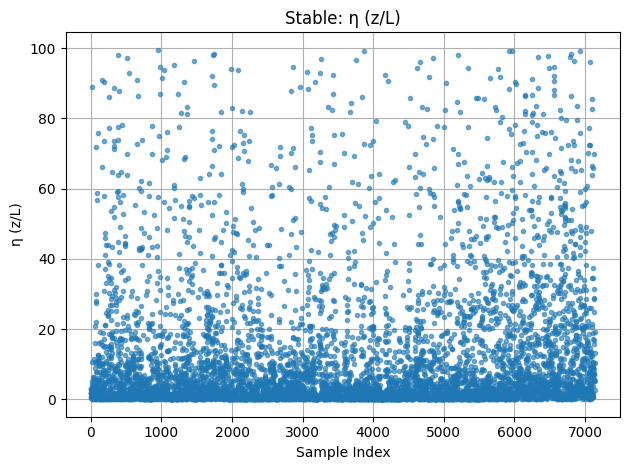

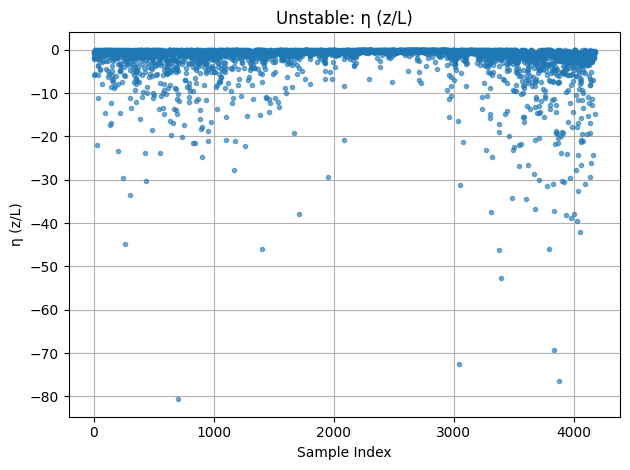

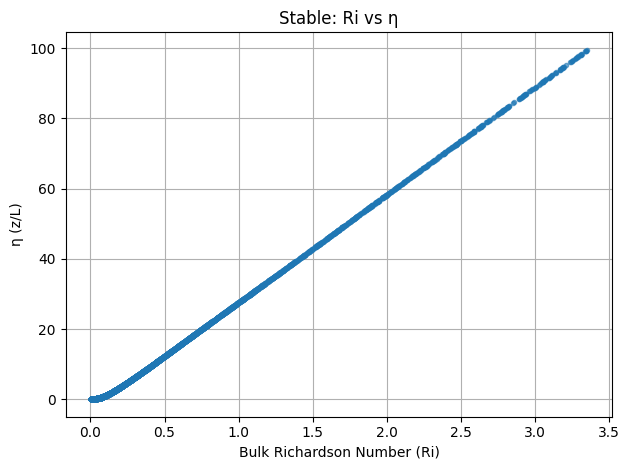

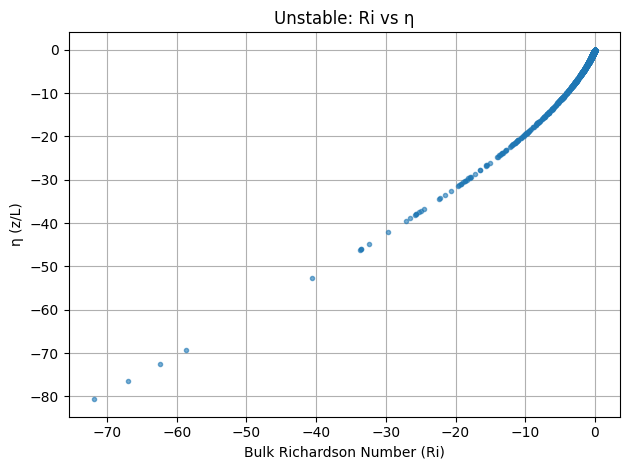

In [42]:
plots = [
    (eta_stable, None, 'Stable: η (z/L)', 'Sample Index', 'η (z/L)'),
    (eta_unstable, None, 'Unstable: η (z/L)', 'Sample Index', 'η (z/L)'),
    (rib_eta_stable, eta_stable, 'Stable: Ri vs η', 'Bulk Richardson Number (Ri)', 'η (z/L)'),
    (rib_eta_unstable, eta_unstable, 'Unstable: Ri vs η', 'Bulk Richardson Number (Ri)', 'η (z/L)')
]

for x, y, title, xlabel, ylabel in plots:

    plt.figure()

    if y is None:
        plt.plot(x, '.', alpha=0.6)
    else:
        plt.plot(x, y, '.', alpha=0.6)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [166]:
cols = ['u0','t0','u8','t8','u16','t16','u27','t27','t57','tavg']

# Stable
df_stable = df.iloc[ts_stable][cols].copy()
df_stable['Ri'] = rib_eta_stable
df_stable['eta'] = eta_stable
df_stable['stamp'] = ts_stable
df_stable = df_stable.set_index('stamp')

# Unstable
df_unstable = df.iloc[ts_unstable][cols].copy()
df_unstable['Ri'] = rib_eta_unstable
df_unstable['eta'] = eta_unstable
df_unstable['stamp'] = ts_unstable
df_unstable = df_unstable.set_index('stamp')

df_stable['u57'] = 0.0
df_unstable['u57'] = 0.0
# ---- Stable ----


In [167]:
# Finding scaling parameters ustar and thetastar
d = 5.37
karman = 0.4
rho = 1.225
cp = 1005


zf = 0.57 / (27-d)

for name, df_, psi in [("Stable", df_stable, psi_stable), ("Unstable", df_unstable, psi_unstable)]:

    T2, T1 = df_['t27'], df_['t57']
    U2 = df_['u27']
    eta = df_['eta']

    dT = T2 - T1

    # ---- Filtering ----
    mask = (dT >= -3) & (dT <= 10) & (U2 >= 0.1) & (U2 <= 20)

    # total = len(df_)
    # retained = mask.sum()
    # discarded = total - retained

    # print(f"{name}: total={total}, retained={retained}, discarded={discarded}")

    # Apply mask
    T2, T1 = T2[mask], T1[mask]
    U2= U2[mask]
    eta = eta[mask]

    denom_m = np.log(1/zf) - psi(eta,'m') + psi(eta*zf,'m')
    denom_h = np.log(1/zf) - psi(eta,'h') + psi(eta*zf,'h')

    u_star = U2* karman / denom_m
    t_star = (T2 - T1) * karman / denom_h

    df_.loc[mask, 'H_most'] = -rho * cp * u_star * t_star
    df_.loc[mask, 'Tau_most'] = rho * u_star**2
    df_.loc[mask, 'H_obs'] = ds.loc[df_[mask].index, 'H']
    df_.loc[mask, 'Tau_obs'] = ds.loc[df_[mask].index, 'Tau']

    # H_low, H_high = df_['H_obs'].quantile([0.005, 1])
    # Tau_low, Tau_high = df_['Tau_obs'].quantile([0, 0.98])
    # mask2 = (
    #     (df_['H_obs'] >= H_low) & (df_['H_obs'] <= H_high) &
    #     (df_['Tau_obs'] >= Tau_low) & (df_['Tau_obs'] <= Tau_high))
    # df_.drop(df_.index[~mask2], inplace=True)



In [193]:
df_stable['Tau_most']

stamp
0        0.015341
1        0.012710
2        0.007989
3        0.007578
4        0.013708
           ...   
11857    0.003948
11858    0.003083
11859    0.005688
11860    0.008152
11861    0.013956
Name: Tau_most, Length: 7028, dtype: float64

In [169]:
df_stable['stability'] = 'stable'
df_unstable['stability'] = 'unstable'

df_all = pd.concat([df_stable, df_unstable]).sort_index()

df_all.to_csv("most_flux_results.csv")

(np.float64(0.6037654606019511), np.float64(96.97650812613581), 58.6720093086984)
(np.float64(0.5161678530662716), np.float64(0.2771250556609647), 0.173064448418154)


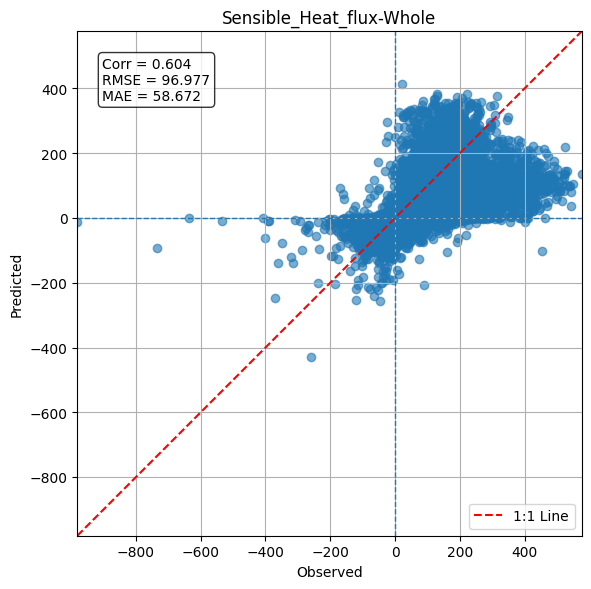

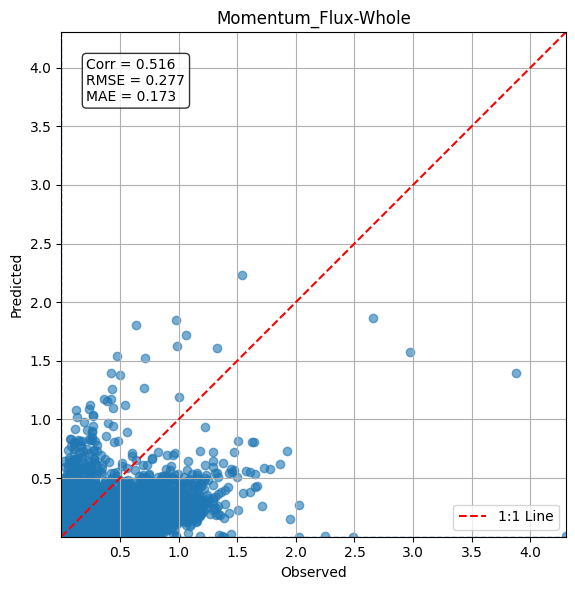

In [146]:
print(results_plot(df_all['H_most'],df_all['H_obs'],'Sensible_Heat_flux-Whole'))
print(results_plot(df_all['Tau_most'],df_all['Tau_obs'],'Momentum_Flux-Whole'))

9642
7020


,Case,corr,RMSE,mae,r2
0,Filtered_Momentum_Flux,0.553459,0.237315,0.156646,0.056854
1,Filtered_Sensible_Heat_Flux,0.684529,81.984074,49.140587,0.418886


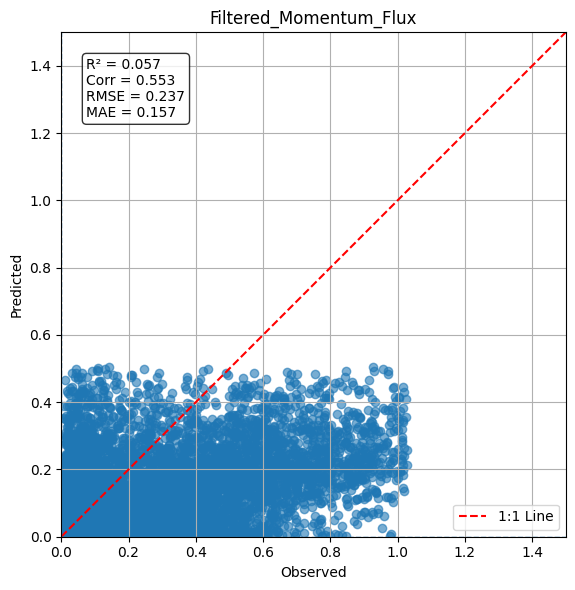

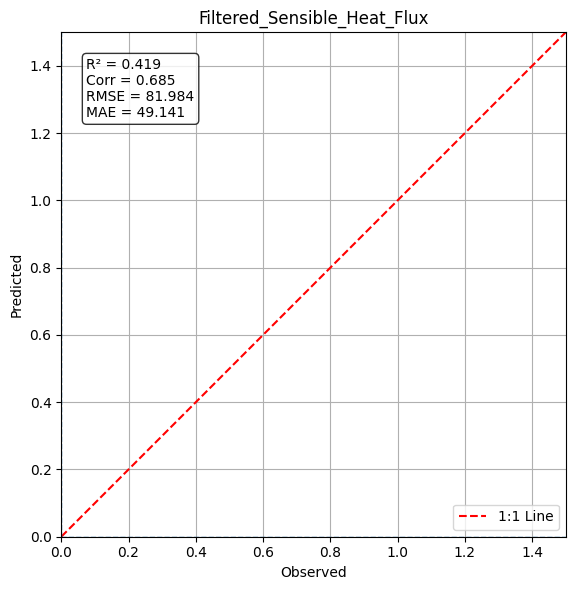

In [194]:

cases = [
    (df_all['Tau_most'],   df_all['Tau_obs'], "Filtered_Momentum_Flux"),
    (df_all['H_most'], df_all['H_obs'], "Filtered_Sensible_Heat_Flux")
]
results=[]
for pred, obs, title in cases:

    # Remove NaNs
    mask = np.isfinite(pred) & np.isfinite(obs)
    pred_, obs_ = pred[mask].values, obs[mask].values

    pred, obs = trim_2percent(pred_, obs_)

    # Sign filtering
    sign_mask = (pred * obs) > 0

    corr,rmse,mae,r2 = results_plot(pred[sign_mask], obs[sign_mask], title)

    results.append([title, corr, rmse, mae,r2])
    print(len(pred[sign_mask]))

# Convert to array
results_df = pd.DataFrame(results, columns=["Case", "corr", "RMSE", "mae","r2"])

results_df


In [180]:
def results_plot(y_pred, y_test, y_title):

    # Remove NaNs safely
    mask = np.isfinite(y_test) & np.isfinite(y_pred)
    y_test = np.array(y_test)[mask]
    y_pred = np.array(y_pred)[mask]

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    corr= np.corrcoef(y_test, y_pred)[0,1]

    # Figure
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(y_test, y_pred, alpha=0.6)

    # Equal axis limits
    # min_val = min(y_test.min(), y_pred.min())
    min_val=0
    max_val=1.5
    # max_val = max(y_test.max(), y_pred.max())
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # 1:1 line
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Line')

    # Zero reference lines
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.axvline(0, linestyle='--', linewidth=1)

    # Labels
    ax.set_title(y_title)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_aspect('equal', adjustable='box')

    # Metrics text box
    textstr = (
        f'R² = {r2:.3f}\n'
        f'Corr = {corr:.3f}\n'
        f'RMSE = {rmse:.3f}\n'
        f'MAE = {mae:.3f}'
    )

    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f'{y_title}.svg')
    #plt.show()

    return corr, rmse, mae,r2


Number of points: 6933
Number of points: 3495
Number of points: 4377
Number of points: 3407


,Case,MAE,RMSE,Correlation,R2
0,MOST_TAU_stable,0.408473,0.213126,0.112902,0.017268
1,MOST_TAU_unstable,0.352755,0.372878,0.292408,-0.463510
2,MOST_H_stable,0.277695,44.473510,22.539476,-0.080641
3,MOST_H_unstable,0.107148,147.320729,111.885481,-0.713469


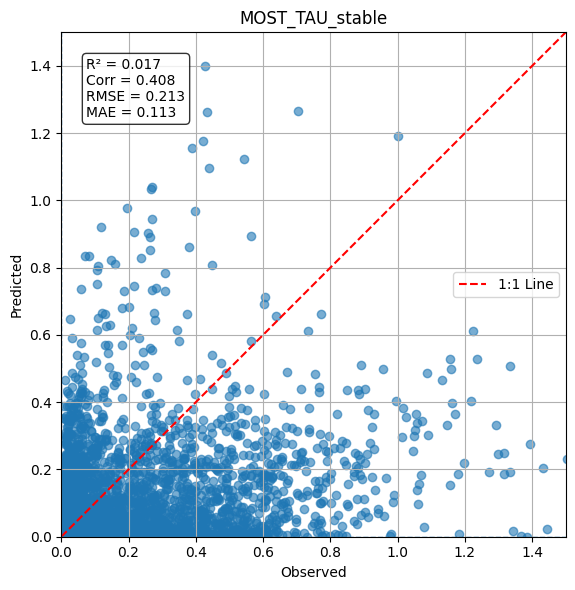

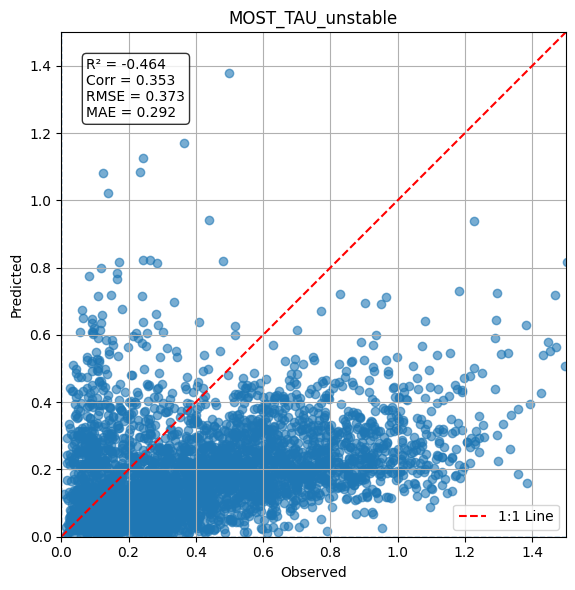

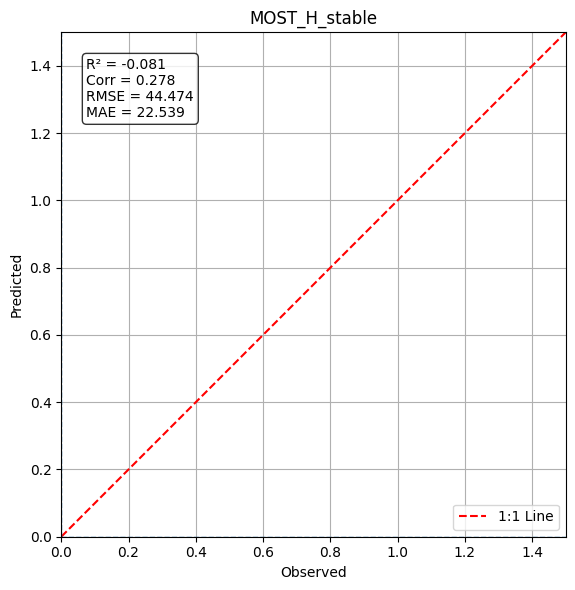

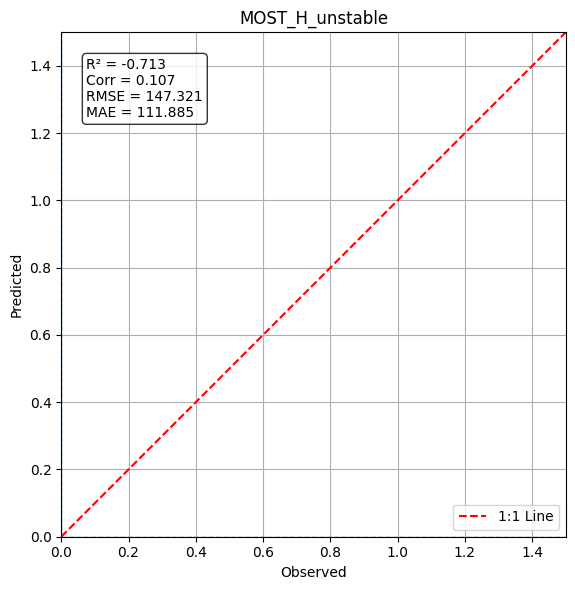

In [181]:
cases = [
    (df_stable['Tau_most'],   df_stable['Tau_obs'], "MOST_TAU_stable"),
    (df_unstable['Tau_most'], df_unstable['Tau_obs'], "MOST_TAU_unstable"),
    (df_stable['H_most'],     df_stable['H_obs'], "MOST_H_stable"),
    (df_unstable['H_most'],   df_unstable['H_obs'], "MOST_H_unstable")
    
]
results = []
for pred, obs, title in cases:

    # Remove NaNs
    mask = np.isfinite(pred) & np.isfinite(obs)
    pred, obs = pred[mask].values, obs[mask].values

    # pred, obs = trim_2percent(pred_, obs_)

    # Sign filtering
    if "H_stable" in title:
        sign_mask = (pred < 0) & (obs < 0)   # stable heat flux should be negative
    else:
        sign_mask = (pred > 0) & (obs > 0)
    print("Number of points:", np.sum(sign_mask))
    
    mae, rmse, corr,r2 = results_plot(pred[sign_mask], obs[sign_mask],title )

    results.append([title, mae, rmse, corr,r2])

# Convert to array
results_df = pd.DataFrame(results, columns=["Case", "MAE", "RMSE", "Correlation","R2"])

results_df

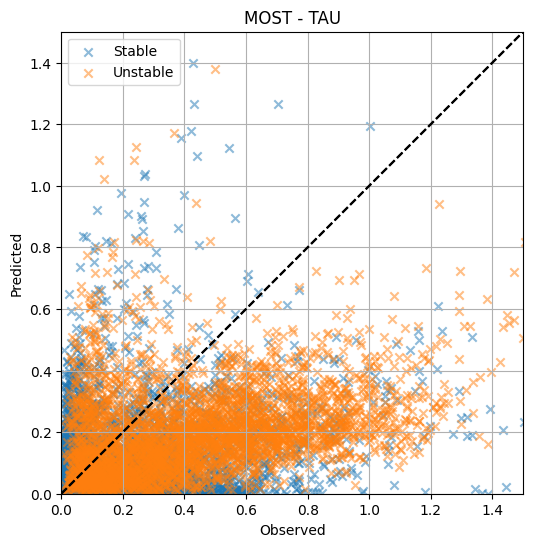

In [196]:
# Extract and clean data
pred_s, obs_s = df_stable[['Tau_most','Tau_obs']].dropna().values.T
pred_u, obs_u = df_unstable[['Tau_most','Tau_obs']].dropna().values.T
H_min, H_max = -100,400
TAU_min, TAU_max = 0,1.5

vmin, vmax = TAU_min, TAU_max




# Sign filtering
pred_s, obs_s = pred_s[(pred_s > 0) & (obs_s > 0)], obs_s[(pred_s > 0) & (obs_s > 0)]
pred_u, obs_u = pred_u[(pred_u > 0) & (obs_u > 0)], obs_u[(pred_u > 0) & (obs_u > 0)]

# Plot
plt.figure(figsize=(6,6))
plt.scatter(obs_s, pred_s, alpha=0.5, label="Stable", marker="x")
plt.scatter(obs_u, pred_u, alpha=0.5, label="Unstable", marker="x")

# 1:1 line
vals = np.concatenate([obs_s, obs_u, pred_s, pred_u])
lims = [vals.min(), vals.max()]
plt.plot(lims, lims, 'k--')

plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)

# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], "k--")

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("MOST - TAU")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig("MOST_TAU_all.svg")
plt.show()

In [94]:
def trim_2percent(pred, obs):

    # Align & remove NaNs
    mask = np.isfinite(pred) & np.isfinite(obs)
    pred = np.array(pred)[mask]
    obs = np.array(obs)[mask]

    # Compute percentile bounds
    p_low_pred, p_high_pred = np.percentile(pred, [2, 98])
    p_low_obs,  p_high_obs  = np.percentile(obs,  [2, 98])

    # Keep only values inside BOTH bounds
    mask_trim = (
        (pred >= p_low_pred) & (pred <= p_high_pred) &
        (obs  >= p_low_obs)  & (obs  <= p_high_obs)
    )

    return pred[mask_trim], obs[mask_trim]

In [ ]:
plt.plot(t_star_s)
plt.plot(t_star_u)
plt.show()
plt.plot(T2_s - T1_s,'.')
plt.plot(T2_u - T1_u,'.')
plt.show()
print(len(T2_s),len(T1_s))
print(len(T2_u),len(T1_u))


plt.plot(psi_stable(df_stable['eta'],'h'))
plt.plot(psi_unstable(df_unstable['eta'],'h'))
plt.show()
plt.plot(psi_stable(df_stable['eta']*zf,'h'))
plt.plot(psi_unstable(df_unstable['eta']*zf,'h'))
plt.show()
plt.plot(psi_stable(df_stable['eta'],'h')-psi_stable(df_stable['eta']*zf,'h'),'.')
plt.plot(psi_unstable(df_unstable['eta'],'h')-psi_unstable(df_unstable['eta']*zf,'h'),'.')
plt.show()

ustar_obs_unstable = ds.loc[Tau_unstable_most.index, 'u*']
ustar_obs_stable = ds.loc[Tau_stable_most.index, 'u*']

results_plot(ustar_obs_stable,u_star_s,'stable u*')
results_plot(ustar_obs_unstable,u_star_u,'unstable u*')


